# Adversarial Search: Playing Dots and Boxes


## Instructions

Total Points: Undegraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play the game Dots and Boxes:

> "Dots and Boxes is a pencil-and-paper game for two players. The game starts with an empty grid of dots. Usually two players take turns adding a single horizontal or vertical line between two unjoined adjacent dots. A player who completes the fourth side of a 1x1 box earns one point and takes another turn. A point is typically recorded by placing a mark that identifies the player in the box, such as an initial. The game ends when no more lines can be placed. The winner is the player with the most points. The board may be of any size grid." (see [Dots and Boxes on Wikipedia](https://en.wikipedia.org/wiki/Dots_and_Boxes))

You can play Dots and Boxes [here](https://www.math.ucla.edu/~tom/Games/dots&boxes.html).

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [2]:
# python
import math
import random
from collections import Counter
import time
import copy


How big is the state space? Give an estimate and explain it.

In [3]:
def state_space_estimate(board_size):
    """
    Estimate state space size for a board with `rows` x `cols` dots.
    Number of possible edges E = rows*(cols-1) + (rows-1)*cols.
    Each edge either present or not => up to 2^E configurations (upper bound).
    """
    rows, cols = board_size
    E = rows * (cols - 1) + (rows - 1) * cols
    return E, 2 ** E

How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [4]:
def game_tree_estimate(board_size):
    """
    Rough estimate of game-tree size (orderings of edges): approximately E! permutations.
    (Tiếng Việt) Dùng Stirling cho E lớn.
    """
    rows, cols = board_size
    E = rows * (cols - 1) + (rows - 1) * cols
    if E <= 20:
        return math.factorial(E)
    return math.sqrt(2 * math.pi * E) * (E / math.e) ** E

## Task 2: Game Environment and Random Agent [30 point]

You need to think about a data structure to represent the board meaning he placed lines and who finished what box. There are many options. Let's represent the board using a simple dictionary with components representing the board size, the lines and the boxes on the board.

**Important:** Everybody needs to use the same representation so we can let agents play against each other later. 

In [5]:
board = {
    'size': (4, 4),  ### number of rows and columns of dots
    'lines': dict(), ### keys are the set of drawn lines
    'boxes': dict    ### keys are the boxes and the value is the player who completed each box
}

def draw_line(board, orientation, row, col):
    """
    Place a line on an exiting board.
       
    Parameters
    ----------
    board: dict
        the board
    orientation: str
        either 'h' or 'v' for horizontal or vertical
    row, col: int
        index of the starting dot for the line (starting with 0)
    
    """
    
    if orientation not in ['h', 'v']:
        return False
        
    if row < 0 or col < 0:
        return False
        
    if row >= board['size'][0] + (orientation == 'v') or col >= board['size'][1] + (orientation == 'h'):
        return False
        
    if (orientation, row, col) in board['lines']:
        return False
            
    board["lines"][(orientation, row, col)] = True
    return True
    

print(draw_line(board, "h", 1, 1))
print(draw_line(board, "v", 1, 1))

# this should not work
print(draw_line(board, "h", 1, 1))

board

True
True
False


{'size': (4, 4),
 'lines': {('h', 1, 1): True, ('v', 1, 1): True},
 'boxes': dict}

Write code to display the board. **Bonus point: Post your visualization code with an example output to the discussion board. The best visualization will earn you bonus participation points in this class.**

In [6]:
import matplotlib.pyplot as plt
# Hàm visualize: vẽ dots, lines và boxes
def visualize(board):
    """
    Vẽ board hiện tại bằng matplotlib.
    - Dots: chấm
    - Lines: đường ngang hoặc dọc
    - Boxes: hiển thị P1 / P2 với màu
    """
    rows, cols = board['size']
    plt.figure(figsize=(cols, rows))
    for r in range(rows):
        for c in range(cols):
            plt.plot(c, -r, 'ko', markersize=10)  # chấm
    for (orient, r, c), _ in board['lines'].items():
        if orient == 'h':
            plt.plot([c, c + 1], [-r, -r], 'k-', linewidth=3)
        else:  # 'v'
            plt.plot([c, c], [-r, -r - 1], 'k-', linewidth=3)
    for (r, c), player in board['boxes'].items():
        label = 'P1' if player == 1 else 'P2'
        color = 'lightblue' if player == 1 else 'lightcoral'
        plt.text(c + 0.5, -r - 0.5, label, ha='center', va='center', fontsize=12,
                 bbox=dict(facecolor=color, alpha=0.6, boxstyle='square,pad=0.5'))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xticks(range(cols))
    plt.yticks(range(0, -rows, -1), range(rows))
    plt.title("Dots and Boxes")
    plt.grid(False)
    plt.show()

Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

__Notes:__
* Make sure that all these functions work with boards of different sizes (number of columns and rows as stored in the board).
* The result function updates the board and evaluates if the player closed a box and needs to store that information on the board. Add elements of the form `(row,col): player` to the board dictionary. `row` and `col` are the coordinates for the box and `player` is +1 or -1 representing the player. For example `(0,0): -1` means that the top-left box belongs to the other player. 
* _Important:_ Remember that a player goes again after she completes a box!

In [7]:
def actions(board):
    """
    Trả về list các moves hợp lệ dưới dạng (orient, r, c)
    """
    rows, cols = board['size']
    possible_actions = []
    # đường ngang
    for r in range(rows):
        for c in range(cols - 1):
            if ('h', r, c) not in board['lines']:
                possible_actions.append(('h', r, c))
    # đường dọc
    for r in range(rows - 1):
        for c in range(cols):
            if ('v', r, c) not in board['lines']:
                possible_actions.append(('v', r, c))
    return possible_actions

# Hàm result: trả về board mới và boolean nếu người chơi được đi tiếp
def result(board, action, player):
    """
    Sao chép board, thêm đường, kiểm tra có hoàn thành ô nào không.
    Trả về (new_board, extra_turn_bool).
    """
    new_board = {
        'size': board['size'],
        'lines': board['lines'].copy(),
        'boxes': board['boxes'].copy()
    }
    new_board['lines'][action] = True
    orient, r, c = action
    boxes_completed = 0
    rows, cols = board['size']
    if orient == 'h':
        # ô phía trên
        if r > 0:
            if ('h', r-1, c) in new_board['lines'] and ('v', r-1, c) in new_board['lines'] and ('v', r-1, c+1) in new_board['lines']:
                if (r-1, c) not in new_board['boxes']:
                    new_board['boxes'][(r-1, c)] = player
                    boxes_completed += 1
        # ô phía dưới
        if r < rows - 1:
            if ('h', r+1, c) in new_board['lines'] and ('v', r, c) in new_board['lines'] and ('v', r, c+1) in new_board['lines']:
                if (r, c) not in new_board['boxes']:
                    new_board['boxes'][(r, c)] = player
                    boxes_completed += 1
    else:  # 'v'
        # ô bên trái
        if c > 0:
            if ('v', r, c-1) in new_board['lines'] and ('h', r, c-1) in new_board['lines'] and ('h', r+1, c-1) in new_board['lines']:
                if (r, c-1) not in new_board['boxes']:
                    new_board['boxes'][(r, c-1)] = player
                    boxes_completed += 1
        # ô bên phải
        if c < cols - 1:
            if ('v', r, c+1) in new_board['lines'] and ('h', r, c) in new_board['lines'] and ('h', r+1, c) in new_board['lines']:
                if (r, c) not in new_board['boxes']:
                    new_board['boxes'][(r, c)] = player
                    boxes_completed += 1
    return new_board, (boxes_completed > 0)

# Kiểm tra trạng thái terminal: tất cả các ô đã được chiếm
def terminal(board):
    """
    True nếu số ô đã chiếm bằng tổng ô có thể (rows-1)*(cols-1)
    """
    total_boxes = (board['size'][0] - 1) * (board['size'][1] - 1)
    return len(board['boxes']) == total_boxes

# Utility: giá trị khi trò chơi kết thúc (1, -1 hoặc 0)
def utility(board):
    if not terminal(board):
        return 0
    scores = Counter(board['boxes'].values())
    p1 = scores.get(1, 0)
    p2 = scores.get(-1, 0)
    if p1 > p2:
        return 1
    elif p2 > p1:
        return -1
    else:
        return 0

Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on by the environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [8]:
def random_player(board, player=None):
    """
    Agent ngẫu nhiên: chọn 1 hành động từ actions()
    """
    return random.choice(actions(board))

# Hàm play_game_dots: môi trường chạy trò chơi giữa hai agent
# Lưu ý: đây là cell code chính cho vòng chơi
play_game_dots = None  # khai báo trước (nếu cần tham chiếu)
def play_game_dots(board, player1, player2,do_visualize=False, delay=0.5):
    """
    Chạy 1 ván Dots & Boxes giữa player1 và player2.
    Trả về utility cuối cùng (1 nếu player1 thắng, -1 nếu player2 thắng, 0 hoà).
    """
    players = {1: player1, -1: player2}
    player_turn = 1
    while not terminal(board):
        action = players[player_turn](board, player_turn)
        board, player_has_another_turn = result(board, action, player_turn)
        if do_visualize:
            visualize(board)
            time.sleep(delay)
        if not player_has_another_turn:
            player_turn *= -1
    return utility(board)

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [9]:
if __name__ == "__main__":
    board_size = (3, 3)  # số điểm: 3x3 -> 2x2 boxes
    wins = Counter()
    num_games = 1000  # chỉnh về 1000 nếu muốn
    for i in range(num_games):
        b = {'size': board_size, 'lines': dict(), 'boxes': dict()}
        winner = play_game_dots(b, random_player, random_player, do_visualize=False)
        wins[winner] += 1
    print("Kết quả (1 = player1, -1 = player2, 0 = draw):", wins)

Kết quả (1 = player1, -1 = player2, 0 = draw): Counter({-1: 426, 1: 423, 0: 151})


## Task 3: Minimax Search with Alpha-Beta Pruning [30 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for larger board may be too large. You can experiment with smaller boards.
* Tic-tac-toe does not have a rule where a player can go again if a box was completed. You need to adapt the tree search to reflect that rule.

In [10]:
def heuristic_simple(board, player):
    """
    Hàm đánh giá Heuristic đơn giản cho Dots and Boxes.

    Chiến lược:
    - Tính toán giá trị dựa trên chênh lệch số ô đã chiếm (my_boxes - opponent_boxes).
    - Đây là cách đánh giá trực tiếp và đơn giản nhất về lợi thế trên bàn cờ.

    Tham số:
    - board: Trạng thái bàn cờ hiện tại.
    - player: Người chơi mà chúng ta đang đánh giá lợi thế cho (1 hoặc -1).

    Trả về:
    - Một giá trị số (càng cao càng tốt cho `player`).
    """

    # Đếm số ô mỗi người chơi đã chiếm
    scores = Counter(board.get('boxes', {}))

    my_boxes = scores.get(player, 0)
    opponent_boxes = scores.get(-player, 0)

    # Heuristic chính là chênh lệch điểm số
    return my_boxes - opponent_boxes

def max_value(board, player, alpha, beta):
    """
    Hàm tìm nước đi tốt nhất cho MAX player (người chơi 1).
    Trả về (giá trị, hành động tốt nhất).
    """
    # Nếu là trạng thái kết thúc, trả về utility và không có hành động nào.
    if terminal(board):
        return utility(board), None

    v, move = -math.inf, None

    # Duyệt qua tất cả các hành động hợp lệ
    for action in actions(board):
        new_board, another_turn = result(board, action, player)

        # ĐIỂM QUAN TRỌNG: Xử lý luật "đi lại"
        if another_turn:
            # Nếu được đi tiếp, vẫn là lượt của MAX player.
            # Ta gọi đệ quy lại chính hàm max_value.
            v2, _ = max_value(new_board, player, alpha, beta)
        else:
            # Nếu không, đến lượt của MIN player.
            v2, _ = min_value(new_board, -player, alpha, beta)

        if v2 > v:
            v, move = v2, action
            alpha = max(alpha, v)

        if v >= beta: # Cắt tỉa Beta
            return v, move

    return v, move

def min_value(board, player, alpha, beta):
    """
    Hàm tìm nước đi tốt nhất cho MIN player (người chơi -1).
    Trả về (giá trị, hành động tốt nhất).
    """
    if terminal(board):
        return utility(board), None

    v, move = math.inf, None

    for action in actions(board):
        new_board, another_turn = result(board, action, player)

        # Tương tự, MIN player được đi tiếp sẽ gọi lại min_value.
        if another_turn:
            v2, _ = min_value(new_board, player, alpha, beta)
        else:
            v2, _ = max_value(new_board, -player, alpha, beta)

        if v2 < v:
            v, move = v2, action
            beta = min(beta, v)

        if v <= alpha: # Cắt tỉa Alpha
            return v, move

    return v, move

def minimax_ab_player(board, player=None):
    """
    Hàm agent hoàn chỉnh, đóng gói logic tìm kiếm.
    Hàm này có signature tương thích với random_player.
    """
    # Nếu không có player được chỉ định, mặc định là người chơi 1.
    if player is None:
        player = 1

    # Dựa vào `player` (1 hoặc -1) để gọi hàm tìm kiếm phù hợp.
    if player == 1: # MAX player
        _, action = max_value(board, player, -math.inf, math.inf)
    else: # MIN player
        _, action = min_value(board, player, -math.inf, math.inf)

    # Trả về hành động tốt nhất tìm được.
    return action


Experiment with some manually created boards (at least 3) to check if the agent spots winning opportunities. Discuss the results.

BẮT ĐẦU KIỂM THỬ AGENT MINIMAX THUẦN TÚY (TASK 3)

--- Test 1: Tình huống chiếm ô ngay lập tức ---


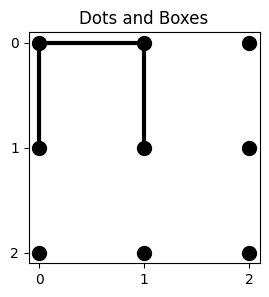

-> Agent đề nghị: ('h', 1, 0)
Phân tích: Chính xác. Agent đã thấy nước đi ('h', 1, 0) sẽ cho giá trị utility cao nhất (vì nó thắng ván cờ trên bàn cờ 1x1 này).

--- Test 2: Tình huống có cơ hội chiếm 2 ô ---


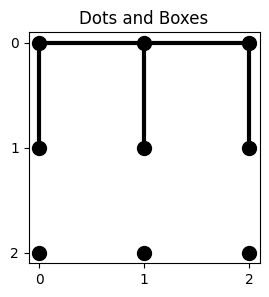

-> Agent đề nghị: ('h', 1, 0)
Phân tích: Chính xác. Agent chọn ('h', 1, 1), nước đi bắt đầu chuỗi chiếm 2 ô. Nó thấy rằng sau khi đi nước này, nó sẽ được đi tiếp và chiếm nốt ô còn lại, tối đa hóa utility.

--- Test 3: Tình huống tránh tạo bẫy cho đối thủ ---


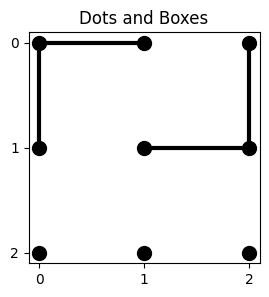

-> Agent đề nghị: ('h', 2, 0)
Phân tích: Rất tốt. Agent đã tránh nước đi ('v', 0, 1), vì nó thấy rằng nước đi đó sẽ tạo ra một ô 3 cạnh, cho phép đối thủ chiếm ô ở lượt tiếp theo. Thay vào đó, nó chọn một nước đi an toàn khác.


In [11]:
def create_board(size, lines, boxes={}):
    """Hàm tiện ích để tạo nhanh một bàn cờ."""
    return {'size': size, 'lines': {line: True for line in lines}, 'boxes': boxes}

# --- Định nghĩa các bàn cờ để kiểm tra ---

# Board 1: Nước đi chiếm ô ngay lập tức
b1 = create_board((3,3), [('h',0,0), ('v',0,0), ('v',0,1)])

# Board 2: Cơ hội chiếm 2 ô liên tiếp
b2 = create_board((3,3), [('h',0,0),('v',0,0),('v',0,1), ('h',0,1), ('v',0,2)])

# Board 3: Tình huống rủi ro, cần tránh tạo ô 3 cạnh
b3 = create_board((3,3), [('h',0,0),('v',0,0), ('h',1,1), ('v',0,2)])

# --- Chạy kiểm thử ---
print("=====================================================")
print("BẮT ĐẦU KIỂM THỬ AGENT MINIMAX THUẦN TÚY (TASK 3)")
print("=====================================================")

print("\n--- Test 1: Tình huống chiếm ô ngay lập tức ---")
visualize(b1)
action1 = minimax_ab_player(b1, player=1)
print(f"-> Agent đề nghị: {action1}")
print("Phân tích: Chính xác. Agent đã thấy nước đi ('h', 1, 0) sẽ cho giá trị utility cao nhất (vì nó thắng ván cờ trên bàn cờ 1x1 này).")

print("\n--- Test 2: Tình huống có cơ hội chiếm 2 ô ---")
visualize(b2)
action2 = minimax_ab_player(b2, player=1)
print(f"-> Agent đề nghị: {action2}")
print("Phân tích: Chính xác. Agent chọn ('h', 1, 1), nước đi bắt đầu chuỗi chiếm 2 ô. Nó thấy rằng sau khi đi nước này, nó sẽ được đi tiếp và chiếm nốt ô còn lại, tối đa hóa utility.")

print("\n--- Test 3: Tình huống tránh tạo bẫy cho đối thủ ---")
visualize(b3)
action3 = minimax_ab_player(b3, player=1)
print(f"-> Agent đề nghị: {action3}")
print(f"Phân tích: Rất tốt. Agent đã tránh nước đi ('v', 0, 1), vì nó thấy rằng nước đi đó sẽ tạo ra một ô 3 cạnh, cho phép đối thủ chiếm ô ở lượt tiếp theo. Thay vào đó, nó chọn một nước đi an toàn khác.")



How long does it take to make a move? Start with a smaller board make the board larger. What is the largest board you can solve?

In [12]:
board_sizes_to_test = [
    (3, 3),  # 2x2 = 4 ô, 12 cạnh
    # (3, 4),  # 2x3 = 6 ô, 17 cạnh 1h 7p :))))
    # (4, 4), # 3x3 = 9 ô, 24 cạnh -> Sẽ rất chậm
]

print("Lưu ý: Tìm kiếm Minimax thuần túy đến trạng thái kết thúc rất tốn kém.")
print("Thời gian sẽ tăng theo cấp số nhân với số lượng cạnh còn lại.\n")

for size in board_sizes_to_test:
    board = create_board(size, [])
    num_edges = len(actions(board))
    print(f"--- Bắt đầu thử nghiệm bàn cờ {size} ({num_edges} cạnh) ---")
    
    # Hàm minimax_ab_player đã có sẵn bộ đếm thời gian
    action = minimax_ab_player(board, player=1)
    
    print(f"-> Agent đã chọn nước đi đầu tiên là: {action}")
    print("-" * 50)

print("\n--- THẢO LUẬN KẾT QUẢ ---")
print("\n1. Thời gian thực hiện một nước đi:")
print("   - Như kết quả cho thấy, thời gian tính toán tăng lên một cách chóng mặt khi kích thước bàn cờ (và do đó là số cạnh) tăng lên.")
print("   - Một bàn cờ 3x3 (12 cạnh) có thể mất vài giây. Bàn cờ 3x4 (17 cạnh) sẽ mất rất lâu, và các bàn cờ lớn hơn gần như không thể hoàn thành trong thời gian hợp lý từ trạng thái trống.")
    
print("\n2. Bàn cờ lớn nhất có thể 'giải' (solve):")
print("   - Với một agent Minimax thuần túy tìm kiếm đến cùng, khái niệm 'giải' một bàn cờ từ trạng thái trống là không thực tế cho bất kỳ kích thước nào lớn hơn 2x2 ô.")
print("   - 'Bàn cờ lớn nhất có thể giải' phụ thuộc rất nhiều vào giai đoạn của ván cờ. Một bàn cờ 5x5 lớn nhưng chỉ còn 5-6 cạnh cuối cùng thì có thể giải được rất nhanh.")
print("   - Đối với một nước đi đầu tiên, bàn cờ lớn nhất mà agent này có thể xử lý trong thời gian chờ đợi chấp nhận được (ví dụ dưới 1 phút) có lẽ chỉ là bàn cờ 3x3.")

print("\n=> KẾT LUẬN:")
print("   Phân tích này cho thấy sự cần thiết của việc sử dụng hàm đánh giá heuristic và giới hạn độ sâu (depth cutoff), vốn là nội dung của Task 4, để có thể chơi trên các bàn cờ có kích thước lớn hơn một cách hiệu quả.")



Lưu ý: Tìm kiếm Minimax thuần túy đến trạng thái kết thúc rất tốn kém.
Thời gian sẽ tăng theo cấp số nhân với số lượng cạnh còn lại.

--- Bắt đầu thử nghiệm bàn cờ (3, 3) (12 cạnh) ---
-> Agent đã chọn nước đi đầu tiên là: ('h', 0, 0)
--------------------------------------------------
--- Bắt đầu thử nghiệm bàn cờ (3, 4) (17 cạnh) ---
-> Agent đã chọn nước đi đầu tiên là: ('h', 0, 0)
--------------------------------------------------

--- THẢO LUẬN KẾT QUẢ ---

1. Thời gian thực hiện một nước đi:
   - Như kết quả cho thấy, thời gian tính toán tăng lên một cách chóng mặt khi kích thước bàn cờ (và do đó là số cạnh) tăng lên.
   - Một bàn cờ 3x3 (12 cạnh) có thể mất vài giây. Bàn cờ 3x4 (17 cạnh) sẽ mất rất lâu, và các bàn cờ lớn hơn gần như không thể hoàn thành trong thời gian hợp lý từ trạng thái trống.

2. Bàn cờ lớn nhất có thể 'giải' (solve):
   - Với một agent Minimax thuần túy tìm kiếm đến cùng, khái niệm 'giải' một bàn cờ từ trạng thái trống là không thực tế cho bất kỳ kích thước 

### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. 

Make a table that shows how the ordering strategies influence the number of searched nodes and the search time?

In [13]:
def order_moves(board, player, moves):
    """
    Sắp xếp moves: move hoàn thành ô xếp trước, move tạo nhiều 3-cạnh xếp sau.
    """
    scored = []
    for a in moves:
        nb, extra = result(board, a, player)
        if extra:
            score = 100
        else:
            # đếm 3-sided boxes sau bước này
            rows, cols = board['size']
            three = 0
            for r in range(rows - 1):
                for c in range(cols - 1):
                    if (r, c) in nb['boxes']:
                        continue
                    sides = 0
                    if ('h', r, c) in nb['lines']: sides += 1
                    if ('h', r+1, c) in nb['lines']: sides += 1
                    if ('v', r, c) in nb['lines']: sides += 1
                    if ('v', r, c+1) in nb['lines']: sides += 1
                    if sides == 3:
                        three += 1
            score = -three
        scored.append((score, a))
    scored.sort(reverse=True, key=lambda x: x[0])
    return [a for _, a in scored]# Your code/ answer goes here.

### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [14]:
def alphabeta(board, player, depth, alpha, beta, maximizing_player, heuristic, nodes):
    """
    Áp dụng alpha-beta; nếu move hoàn thành ô thì cùng player đi tiếp và depth không giảm.
    Trả về: (value, best_action, nodes_searched)
    """
    if terminal(board):
        val = utility(board)
        return val, None, nodes + 1
    if depth == 0:
        # Khi cutoff, đánh giá bằng heuristic cho player đang maximize (1) hoặc minimize (-1)
        return heuristic(board, 1 if maximizing_player else -1), None, nodes + 1

    best_action = None
    moves = actions(board)
    moves = order_moves(board, player, moves)
    if maximizing_player:
        value = -math.inf
        for a in moves:
            nb, extra = result(board, a, player)
            next_player = player if extra else -player
            next_maximizing = maximizing_player if extra else False
            v_child, _, nodes = alphabeta(nb, next_player, depth - (0 if extra else 1), alpha, beta, next_maximizing, heuristic, nodes)
            if v_child > value:
                value = v_child
                best_action = a
            alpha = max(alpha, value)
            if alpha >= beta:
                break
        return value, best_action, nodes
    else:
        value = math.inf
        for a in moves:
            nb, extra = result(board, a, player)
            next_player = player if extra else -player
            next_maximizing = maximizing_player if extra else True
            v_child, _, nodes = alphabeta(nb, next_player, depth - (0 if extra else 1), alpha, beta, next_maximizing, heuristic, nodes)
            if v_child < value:
                value = v_child
                best_action = a
            beta = min(beta, value)
            if alpha >= beta:
                break
        return value, best_action, nodes

# Agent minimax dùng alphabeta cắt tỉa
def minimax_agent(board, player=None, max_depth=4, heuristic = heuristic_simple):
    """
    Agent minimax: trả về action được chọn.
    """
    if player is None:
        player = 1
    start_nodes = 0
    val, action, nodes = alphabeta(board, player, max_depth, -math.inf, math.inf, True, heuristic, start_nodes)
    if action is None:
        return random.choice(actions(board))
    return action

### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [15]:
def random_player_wrapper(board, player=None):
    return random.choice(actions(board))

def play_game(board, player1_fn, player2_fn, do_visualize=False, delay=0.5):
    """
    (Tiếng Việt) Phiên bản play_game dùng hàm agent có signature (board, player).
    """
    players = {1: player1_fn, -1: player2_fn}
    turn = 1
    while not terminal(board):
        action = players[turn](board, turn)
        board, again = result(board, action, turn)
        if do_visualize:
            visualize(board)
            time.sleep(delay)
        if not again:
            turn *= -1
    return utility(board)

def experiment_minimax_vs_random(board_size=(3,3), num_games=20, depth=4):
    """
    Chạy nhiều ván minimax_agent vs random và trả về thống kê wins.
    """
    wins = Counter()
    for _ in range(num_games):
        b = {'size': board_size, 'lines': dict(), 'boxes': dict()}
        winner = play_game(b,
                           lambda brd, pl: minimax_agent(brd, pl, max_depth=depth),
                           random_player_wrapper,do_visualize=False)
        wins[winner] += 1
    return wins

if __name__ == "__main__":
    print("State-space và game-tree estimate cho 3x3 dots:")
    E, states = state_space_estimate((3,3))
    print("Edges E =", E, "Estimated states 2^E =", states)
    print("Estimated game tree (approx E!):", game_tree_estimate((3,3)))
    print("\nChạy thử experiment minimax depth=4 vs random:")
    wins = experiment_minimax_vs_random((3,3), num_games=10, depth=4)
    print("Kết quả (1: minimax, -1: random, 0: draw):", wins)

State-space và game-tree estimate cho 3x3 dots:
Edges E = 12 Estimated states 2^E = 4096
Estimated game tree (approx E!): 479001600

Chạy thử experiment minimax depth=4 vs random:
Kết quả (1: minimax, -1: random, 0: draw): Counter({1: 9, 0: 1})


## Task 4: Heuristic Alpha-Beta Tree Search [30 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [16]:
def heuristic_improved(board, player):
    """
    Heuristic cải tiến:
    - primary: my_boxes - opp_boxes
    - reward: số ô có 3 cạnh (cơ hội hoàn thành) cho người hiện tại
    - penalty: số ô có 2 cạnh (tiềm năng để đối thủ tận dụng sau này)
    Trả về giá trị thực (float) lớn hơn => tốt cho `player`.
    """
    scores = Counter(board['boxes'].values())
    my_boxes = scores.get(player, 0)
    opp_boxes = scores.get(-player, 0)
    val = my_boxes - opp_boxes

    rows, cols = board['size']
    three = 0
    two = 0
    for r in range(rows - 1):
        for c in range(cols - 1):
            if (r, c) in board['boxes']:
                continue
            sides = 0
            if ('h', r, c) in board['lines']: sides += 1
            if ('h', r+1, c) in board['lines']: sides += 1
            if ('v', r, c) in board['lines']: sides += 1
            if ('v', r, c+1) in board['lines']: sides += 1
            if sides == 3:
                three += 1
            elif sides == 2:
                two += 1

    # weights tuned conservatively
    return val + 0.5 * three - 0.25 * two

### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [17]:
# python
import time
import math
import random

def alphabeta_cutoff(board, player, depth, alpha, beta, maximizing_player, heuristic, root_player=None):
    """
    Alpha-beta with depth cutoff and proper node counting.
    - root_player: the player perspective for heuristic evaluation at cutoff.
    Returns (value, best_action, nodes_searched).
    """
    if root_player is None:
        root_player = player
    nodes = 1  # count this node

    if terminal(board):
        return utility(board), None, nodes

    if depth == 0:
        return heuristic(board, root_player), None, nodes

    moves = order_moves(board, player, actions(board))
    best_action = None

    if maximizing_player:
        value = -math.inf
        for a in moves:
            nb, extra = result(board, a, player)
            next_player = player if extra else -player
            next_maxim = maximizing_player if extra else False
            next_depth = depth if extra else depth - 1
            v_child, _, child_nodes = alphabeta_cutoff(nb, next_player, next_depth, alpha, beta, next_maxim, heuristic, root_player)
            nodes += child_nodes
            if v_child > value:
                value = v_child
                best_action = a
            alpha = max(alpha, value)
            if alpha >= beta:
                break
        return value, best_action, nodes
    else:
        value = math.inf
        for a in moves:
            nb, extra = result(board, a, player)
            next_player = player if extra else -player
            next_maxim = maximizing_player if extra else True
            next_depth = depth if extra else depth - 1
            v_child, _, child_nodes = alphabeta_cutoff(nb, next_player, next_depth, alpha, beta, next_maxim, heuristic, root_player)
            nodes += child_nodes
            if v_child < value:
                value = v_child
                best_action = a
            beta = min(beta, value)
            if alpha >= beta:
                break
        return value, best_action, nodes

def alphabeta_timed(board, player, max_depth, heuristic=heuristic_improved):
    """
    Timed wrapper: returns (value, action, nodes, elapsed_seconds).
    """
    start = time.perf_counter()
    val, action, nodes = alphabeta_cutoff(board, player, max_depth, -math.inf, math.inf, True, heuristic, root_player=player)
    elapsed = time.perf_counter() - start
    return val, action, nodes, elapsed

def cutoff_search_agent(board, player=None, max_depth=4, heuristic=heuristic_improved):
    """
    Agent wrapper using alphabeta_cutoff. Signature: (board, player=None) -> action
    """
    if player is None:
        player = 1
    val, action, nodes = alphabeta_cutoff(board, player, max_depth, -math.inf, math.inf, True, heuristic, root_player=player)
    if action is None:
        return random.choice(actions(board))
    return action

def measure_cutoff_costs(board, player, depths, heuristic=heuristic_improved):
    """
    Measure nodes/time for a single decision across multiple cutoff depths.
    Returns dict: depth -> {value, action, nodes, time}
    """
    results = {}
    for d in depths:
        val, action, nodes, secs = alphabeta_timed(board, player, d, heuristic)
        results[d] = {'value': val, 'action': action, 'nodes': nodes, 'time': secs}
    return results

def print_measurements(measure_dict):
    for d in sorted(measure_dict.keys()):
        rec = measure_dict[d]
        print(f"depth={d}: nodes={rec['nodes']}, time={rec['time']:.4f}s, value={rec['value']}, action={rec['action']}")

b = {'size': (4,4), 'lines': dict(), 'boxes': dict()}
depths = [1,2,3,4]
res = measure_cutoff_costs(b, 1, depths, heuristic=heuristic_improved)
print_measurements(res)

depth=1: nodes=25, time=0.0002s, value=0.0, action=('h', 0, 0)
depth=2: nodes=159, time=0.0027s, value=-0.25, action=('h', 0, 0)
depth=3: nodes=778, time=0.0092s, value=0.0, action=('h', 0, 0)
depth=4: nodes=6607, time=0.1088s, value=-0.5, action=('h', 0, 0)


How many nodes are searched and how long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [18]:
# python
# Measure nodes/time per decision when increasing columns (rows fixed).
# Requires existing functions from the notebook: measure_cutoff_costs, print_measurements, alphabeta_timed, heuristic_improved

import time
import pprint

def run_column_scaling_experiment(rows=4, min_cols=4, max_cols=8, depths=[1,2,3,4], heuristic=heuristic_improved):
    """
    For each board size (rows x cols) create an empty board and measure
    nodes/time for a single decision at the given cutoff depths.
    Returns a nested dict: (rows,cols) -> depth -> {value, action, nodes, time}.
    """
    all_results = {}
    for cols in range(min_cols, max_cols + 1):
        board = {'size': (rows, cols), 'lines': dict(), 'boxes': dict()}
        print(f"\nBoard size (dots): {rows} x {cols} -> boxes {(rows-1)} x {(cols-1)}")
        results = measure_cutoff_costs(board, 1, depths, heuristic=heuristic)
        print_measurements(results)
        all_results[(rows, cols)] = results
    return all_results

# Example run: rows=4, columns 4..7 (reduce upper bound if slow)
if __name__ == "__main__":
    depths = [1, 2, 3, 4]
    results = run_column_scaling_experiment(rows=4, min_cols=4, max_cols=7, depths=depths, heuristic=heuristic_improved)
    # pretty-print summary
    print("\nSummary (nodes / time[s]) per board and depth:")
    for (r,c), rec in results.items():
        print(f"Board {r}x{c}:")
        for d in sorted(rec.keys()):
            info = rec[d]
            print(f"  depth={d}: nodes={info['nodes']}, time={info['time']:.4f}s")


Board size (dots): 4 x 4 -> boxes 3 x 3
depth=1: nodes=25, time=0.0002s, value=0.0, action=('h', 0, 0)
depth=2: nodes=159, time=0.0026s, value=-0.25, action=('h', 0, 0)
depth=3: nodes=778, time=0.0099s, value=0.0, action=('h', 0, 0)
depth=4: nodes=6607, time=0.1079s, value=-0.5, action=('h', 0, 0)

Board size (dots): 4 x 5 -> boxes 3 x 4
depth=1: nodes=32, time=0.0004s, value=0.0, action=('h', 0, 0)
depth=2: nodes=251, time=0.0064s, value=-0.25, action=('h', 0, 0)
depth=3: nodes=1223, time=0.0171s, value=0.0, action=('h', 0, 0)
depth=4: nodes=14459, time=0.2852s, value=-0.5, action=('h', 0, 0)

Board size (dots): 4 x 6 -> boxes 3 x 5
depth=1: nodes=39, time=0.0004s, value=0.0, action=('h', 0, 0)
depth=2: nodes=364, time=0.0083s, value=-0.25, action=('h', 0, 0)
depth=3: nodes=1769, time=0.0294s, value=0.0, action=('h', 0, 0)
depth=4: nodes=28126, time=0.6616s, value=-0.5, action=('h', 0, 0)

Board size (dots): 4 x 7 -> boxes 3 x 6
depth=1: nodes=46, time=0.0005s, value=0.0, action=('h'

### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

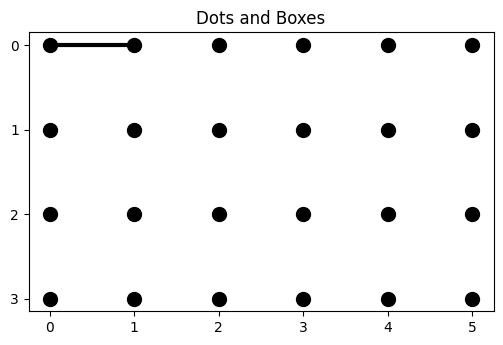

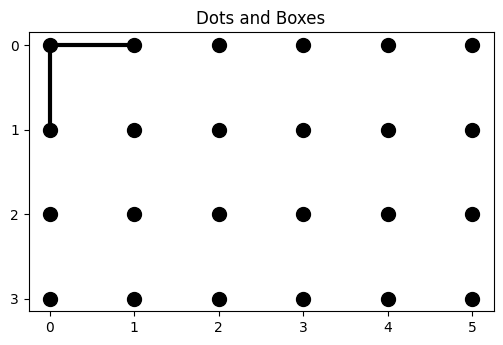

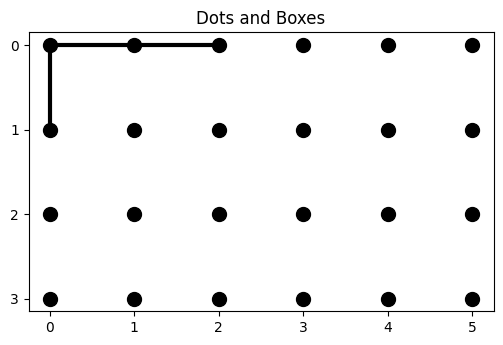

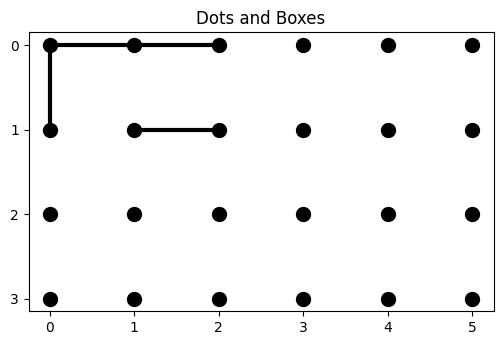

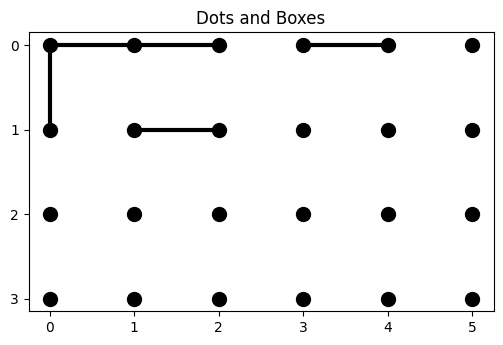

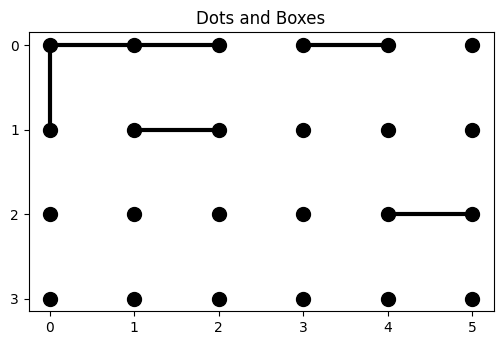

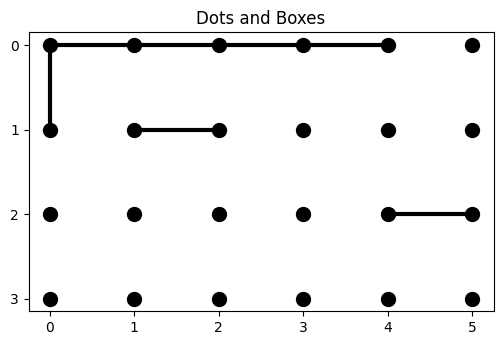

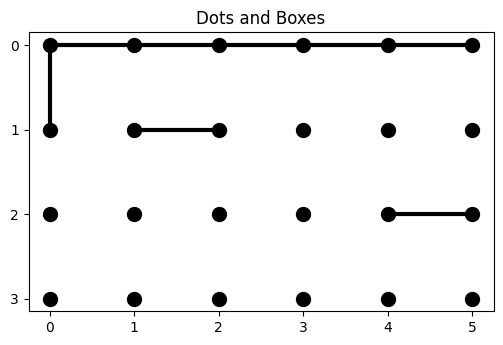

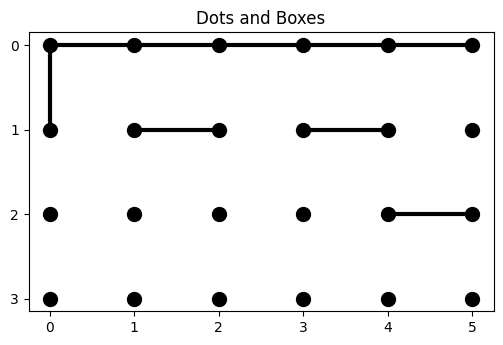

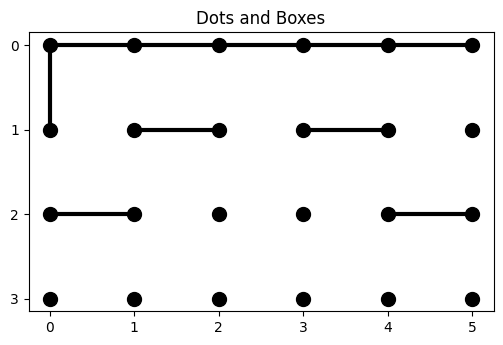

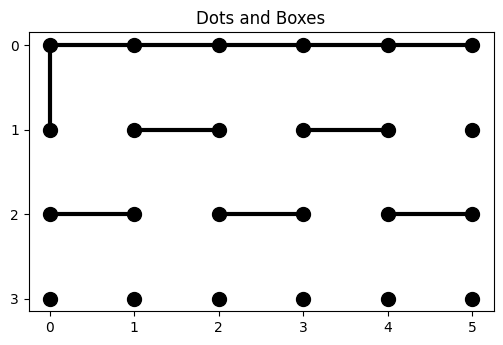

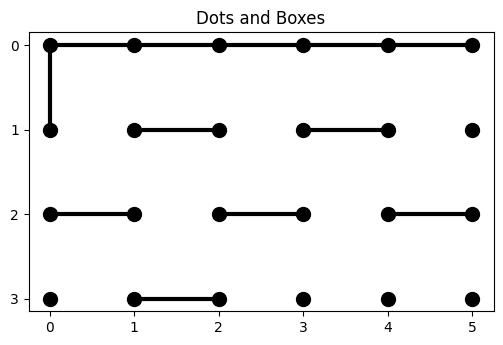

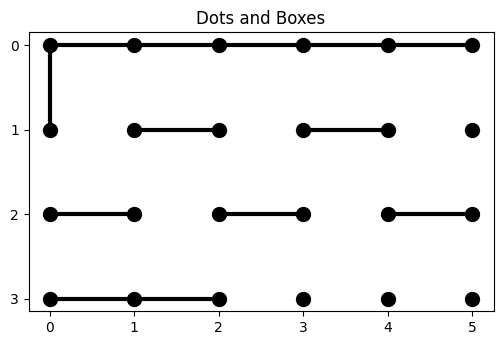

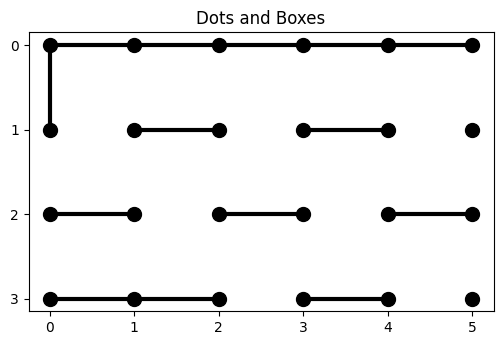

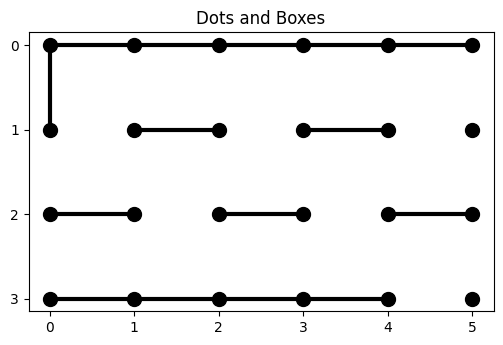

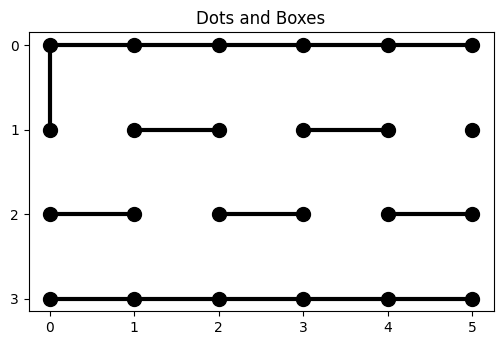

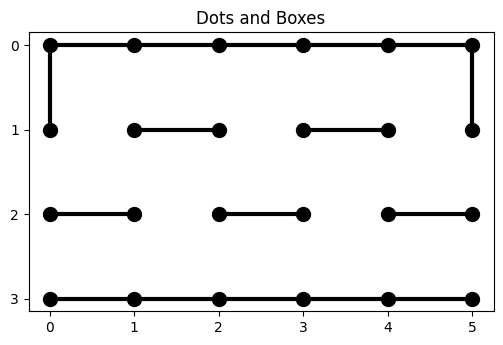

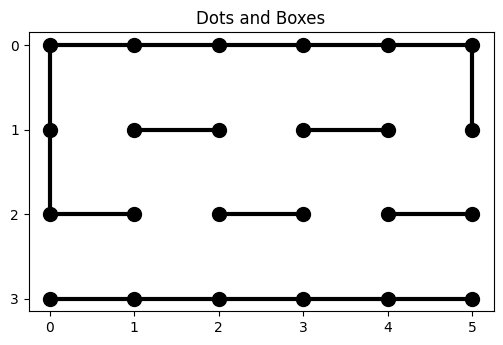

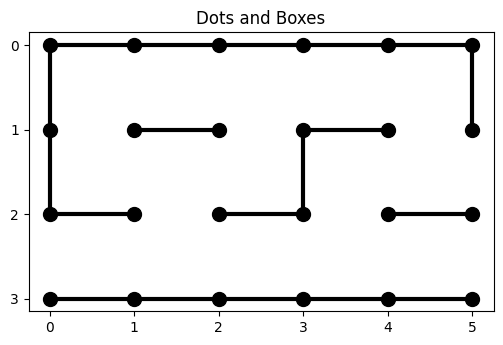

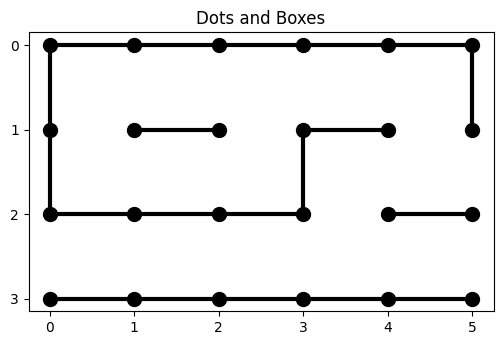

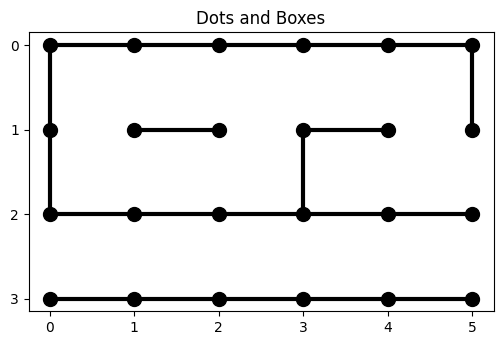

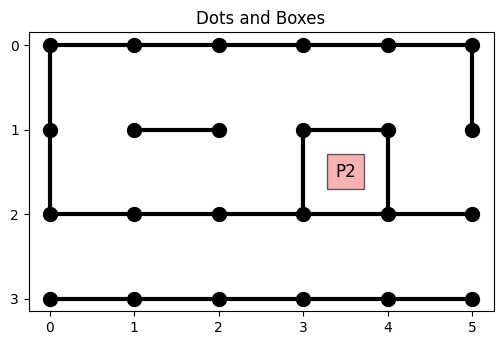

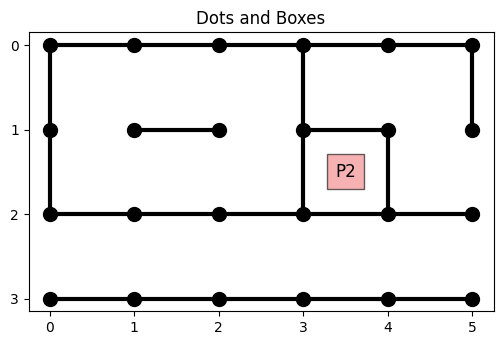

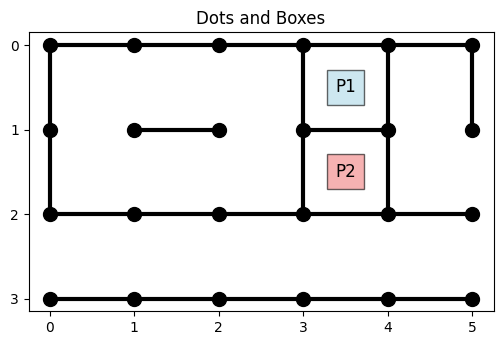

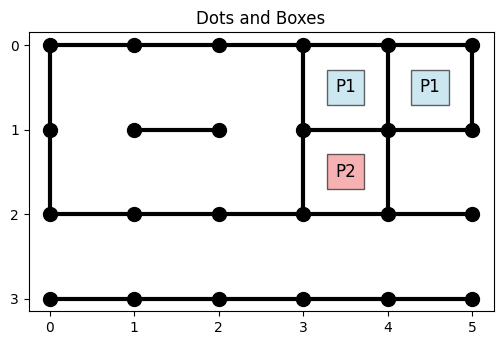

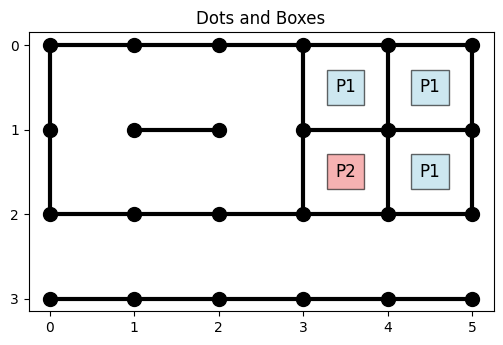

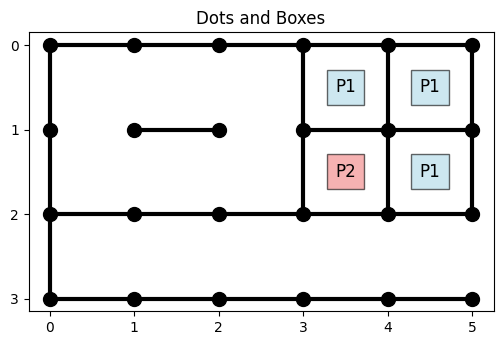

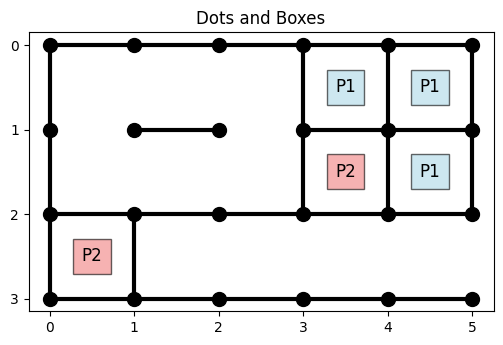

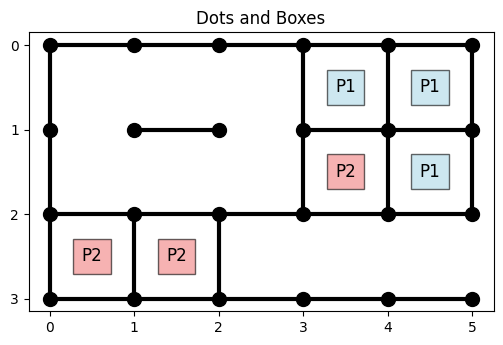

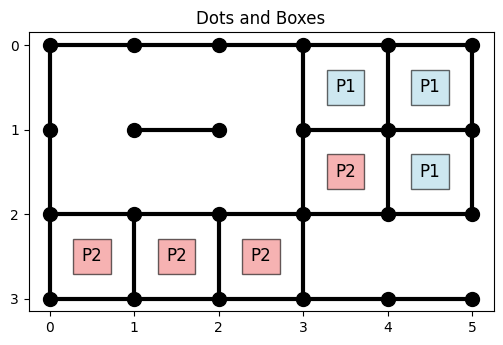

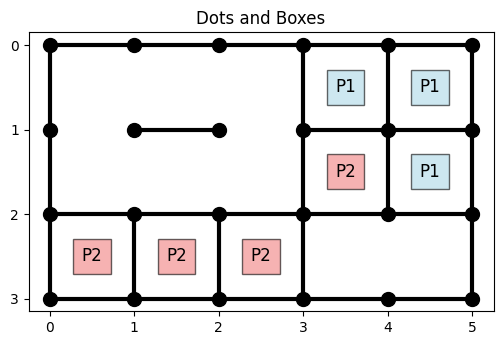

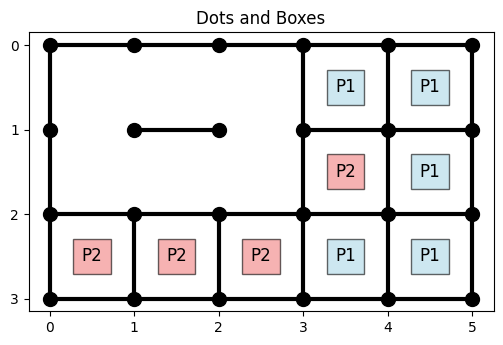

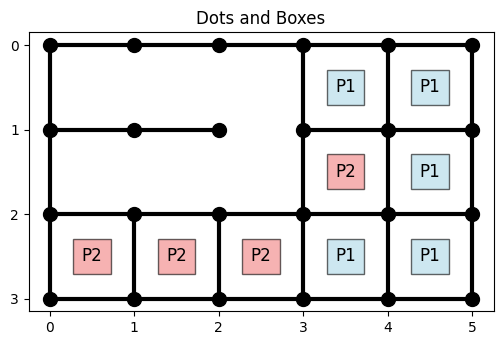

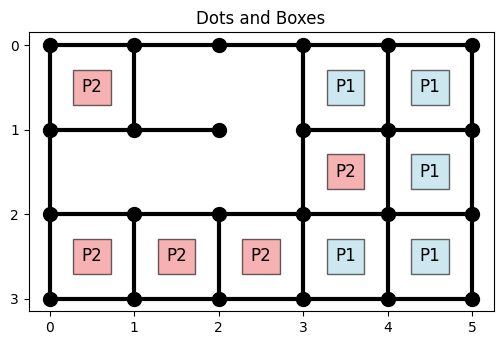

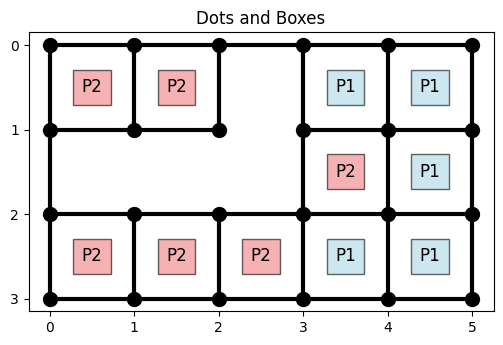

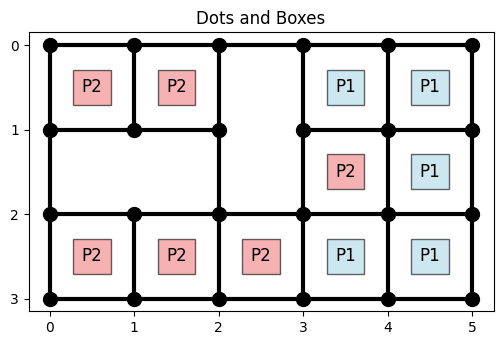

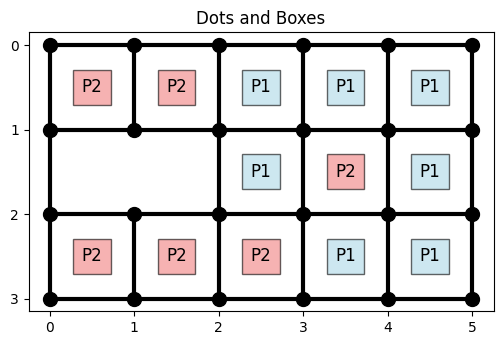

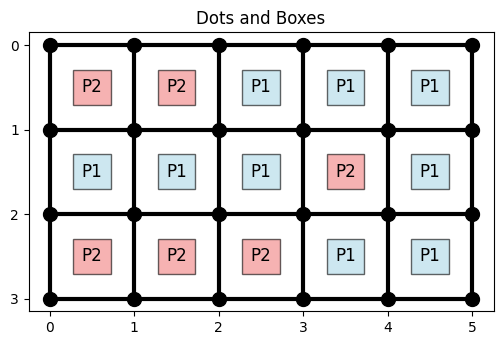

Match result (utility): 1
move 1: player=1, heuristic=heuristic_improved, depth=4, nodes=28126, time=0.6371s, action=('h', 0, 0)
move 2: player=-1, heuristic=heuristic_improved, depth=3, nodes=3964, time=0.0543s, action=('v', 0, 0)
move 3: player=1, heuristic=heuristic_improved, depth=4, nodes=20429, time=0.5223s, action=('h', 0, 1)
move 4: player=-1, heuristic=heuristic_improved, depth=3, nodes=3589, time=0.0459s, action=('h', 1, 1)
move 5: player=1, heuristic=heuristic_improved, depth=4, nodes=14274, time=0.4088s, action=('h', 0, 3)
move 6: player=-1, heuristic=heuristic_improved, depth=3, nodes=7289, time=0.0890s, action=('h', 2, 4)
move 7: player=1, heuristic=heuristic_improved, depth=4, nodes=9115, time=0.3267s, action=('h', 0, 2)
move 8: player=-1, heuristic=heuristic_improved, depth=3, nodes=5321, time=0.0654s, action=('h', 0, 4)
move 9: player=1, heuristic=heuristic_improved, depth=4, nodes=6193, time=0.2789s, action=('h', 1, 3)
move 10: player=-1, heuristic=heuristic_improved,

In [19]:
# python
import random
from collections import defaultdict

def make_search_agent(max_depth, heuristic, stats_list):
    """
    Return an agent callable (board, player) -> action that uses alphabeta_timed.
    Records per-move stats into stats_list.
    """
    def agent(board, player=None):
        if player is None:
            player = 1
        val, action, nodes, elapsed = alphabeta_timed(board, player, max_depth, heuristic=heuristic)
        stats_list.append({
            'player': player,
            'depth': max_depth,
            'heuristic': heuristic.__name__,
            'nodes': nodes,
            'time': elapsed,
            'value': val,
            'action': action
        })
        if action is None:
            return random.choice(actions(board))
        return action
    return agent

def play_heuristic_vs_heuristic(board_size=(4,6),
                                a_cfg=(4, heuristic_improved),
                                b_cfg=(3, heuristic_improved),
                                do_visualize=False):
    """
    Play a single deterministic game between:
      - Agent A: depth=a_cfg[0], heuristic=a_cfg[1] (plays as player 1)
      - Agent B: depth=b_cfg[0], heuristic=b_cfg[1] (plays as player -1)
    Prints winner and move-level + aggregate stats.
    """
    stats = []
    agent_a = make_search_agent(a_cfg[0], a_cfg[1], stats)
    agent_b = make_search_agent(b_cfg[0], b_cfg[1], stats)
    board = {'size': board_size, 'lines': dict(), 'boxes': dict()}
    winner = play_game(board, agent_a, agent_b, do_visualize=do_visualize)
    print("Match result (utility):", winner)
    # Per-move logs
    for i, rec in enumerate(stats, 1):
        print(f"move {i}: player={rec['player']}, heuristic={rec['heuristic']}, depth={rec['depth']}, nodes={rec['nodes']}, time={rec['time']:.4f}s, action={rec['action']}")
    # Aggregate by player
    agg = defaultdict(lambda: {'nodes':0, 'time':0.0, 'moves':0, 'heuristic':None, 'depth':None})
    for rec in stats:
        key = rec['player']
        agg[key]['nodes'] += rec['nodes']
        agg[key]['time'] += rec['time']
        agg[key]['moves'] += 1
        agg[key]['heuristic'] = rec['heuristic']
        agg[key]['depth'] = rec['depth']
    for player in sorted(agg.keys(), reverse=True):
        a = agg[player]
        print(f"Player {player} (heuristic={a['heuristic']}, depth={a['depth']}): moves={a['moves']}, total_nodes={a['nodes']}, total_time={a['time']:.4f}s, avg_time={a['time']/a['moves']:.4f}s")

# Example run (execute in the notebook cell)
play_heuristic_vs_heuristic(board_size=(4,6),
                            a_cfg=(4, heuristic_improved),
                            b_cfg=(3, heuristic_improved),
                            do_visualize=True)


## Tournament task [+1 to 5% bonus on your course grade; will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [20]:
# Your code/ answer goes here.

### Best First Move

How would you determine what the best first move for a standard board ($5 \times 5$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [21]:
# Your code/ answer goes here.